## Laplace equation in 2D

Here we study a harmonic function on the region $[0,1]\times[0,L]$. The function satisfies Laplace’s equation,

$$
u_{xx} + u_{yy} = 0,
$$

with zero boundary values on the vertical sides and the same prescribed boundary profile on the top and bottom:

$$
u(0,y)=u(1,y)=0, \qquad u(x,0)=u(x,L)=F(x)
$$

The boundary function is chosen as a short sine series,

$$ F(x) = f_1(x) - \frac 1 9 f_3(x) + \frac 1 {25} f_5(x) \quad \text{where} \quad f_n(x) = \sin(n \pi x)$$

Because the boundary conditions in $x$ are zero at $x=0$ and $x=1$, sine functions are the natural basis. Each sine mode is extended into the interior using hyperbolic cosine functions in $y$. Changing $L$ changes how far the top and bottom boundaries are separated, which affects how strongly the boundary data influences the middle of the rectangle.

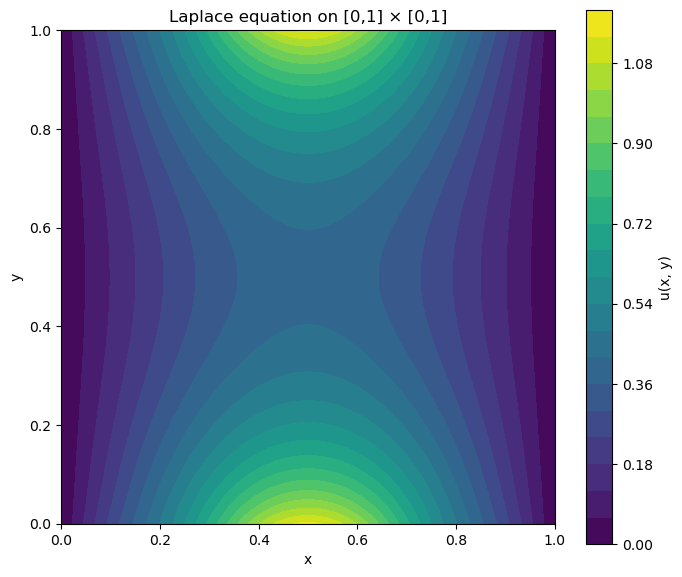

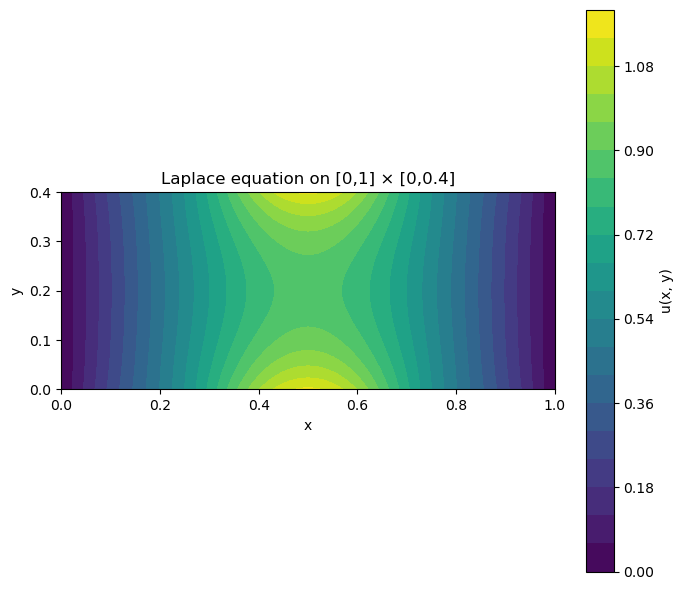

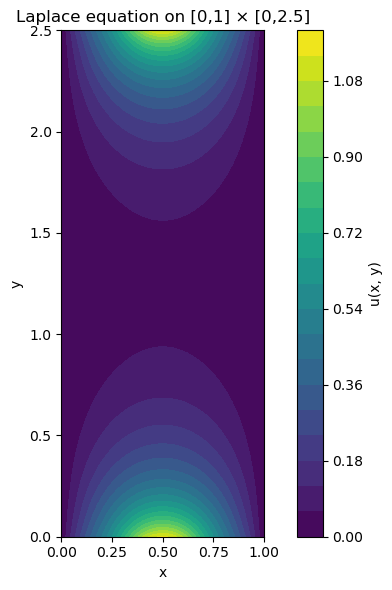

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# Compute the solution of Laplace's equation on [0,1] x [0,L]
# using a sine series in x and hyperbolic cosine in y
def laplace_rectangle_solution(X, Y, L, modes):

    u = np.zeros_like(X)  # initialize solution array

    # Sum over sine modes
    for n, coefficient in modes:
        u += (
            coefficient
            * np.sin(n * np.pi * X)
            * np.cosh(n * np.pi * (Y - L/2))
            / np.cosh(n * np.pi * L/2)
        )

    return u


# Plot the solution for a given rectangle height L
def plot_laplace_rectangle(L, N=100):

    # Create grid over [0,1] x [0,L]
    x = np.linspace(0, 1, N + 1)
    y = np.linspace(0, L, N + 1)

    X, Y = np.meshgrid(x, y)

    # Define the sine modes from the boundary function F(x)
    modes = [
        (1, 1),
        (3, -1/9),
        (5, 1/25),
    ]

    # Compute solution
    u = laplace_rectangle_solution(X, Y, L, modes)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(7, 6))

    contour = ax.contourf(X, Y, u, levels = 20) # 20 contours
    cbar = fig.colorbar(contour, ax = ax) # Add colorbar (linked to axis for proper layout)
    cbar.ax.set_ylabel("u(x, y)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Laplace equation on [0,1] × [0,{L}]")

    ax.set_aspect("equal") # Ensure correct geometry
    plt.tight_layout() # Clean layout
    plt.show()


# --- Run examples ---

# Square case
plot_laplace_rectangle(L = 1)

# Compare different rectangle heights
for L in [0.4, 2.5]:
    plot_laplace_rectangle(L)

By varying $ L $, we can observe how the geometry of the domain influences the harmonic extension of the boundary data: for small $ L $, the boundary conditions interact strongly across the domain, while for large $ L $, the interior becomes less influenced by the opposite boundary.